# Linear Models: a visual, executable learning path

**Flow:** data → split → fit → diagnose → regularize (CV) → classify → practice. Every figure below is generated by the cell immediately before it, and every model is evaluated on held-out data.

## 1. Setup and versions
Deterministic synthetic data lets you change one parameter at a time. We import only what we use, print versions, and adopt a single colorblind-safe (Okabe–Ito) palette.

In [1]:
import sys
import numpy as np
import scipy
import sklearn
import matplotlib
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression, Ridge, RidgeCV, Lasso, LassoCV, LogisticRegression
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.dummy import DummyRegressor
from sklearn.metrics import (r2_score, mean_squared_error, confusion_matrix,
                             accuracy_score, roc_curve, roc_auc_score)

rng = np.random.default_rng(7)

OKABE_ITO = [
    '#0072B2',  # blue
    '#E69F00',  # orange
    '#009E73',  # bluish green
    '#D55E00',  # vermillion
    '#CC79A7',  # reddish purple
    '#56B4E9',  # sky blue
    '#F0E442',  # yellow
    '#000000',  # black
]

print('Python      :', sys.version.split()[0])
print('numpy       :', np.__version__)
print('scipy       :', scipy.__version__)
print('scikit-learn:', sklearn.__version__)
print('matplotlib  :', matplotlib.__version__)


Python      : 3.9.25
numpy       : 1.26.4
scipy       : 1.13.1
scikit-learn: 1.4.2
matplotlib  : 3.8.4


## 2. Ordinary least squares (OLS)
OLS minimizes the **sum of squared vertical residuals**. The vertical segments are residuals (actual minus prediction) on the training data.

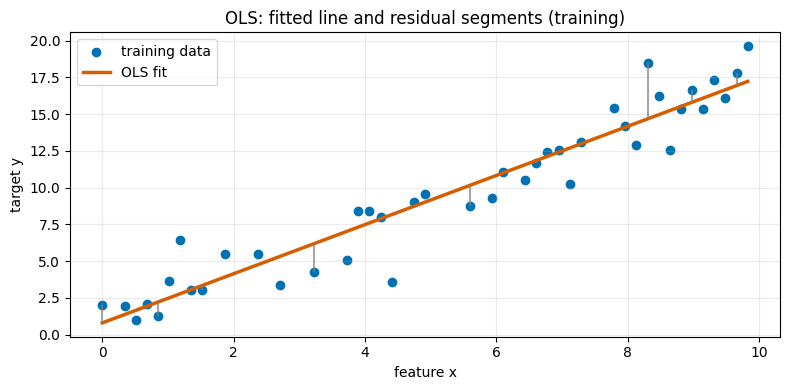

In [2]:
x = np.linspace(0, 10, 60)
y = 2 + 1.5 * x + rng.normal(0, 2, size=x.size)
X = x[:, None]

# Split BEFORE fitting.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=7
)
ols = LinearRegression().fit(X_train, y_train)
train_pred = ols.predict(X_train)

order = np.argsort(X_train[:, 0])
plt.figure(figsize=(8, 4))
plt.scatter(X_train[:, 0], y_train, color=OKABE_ITO[0], label='training data')
plt.plot(X_train[order, 0], train_pred[order], color=OKABE_ITO[3], lw=2.5,
         label='OLS fit')
for xi, yi, pi in zip(X_train[order, 0][::4], y_train[order][::4],
                      train_pred[order][::4]):
    plt.vlines(xi, min(yi, pi), max(yi, pi), color='0.5', alpha=0.7)
plt.title('OLS: fitted line and residual segments (training)')
plt.xlabel('feature x'); plt.ylabel('target y')
plt.legend(); plt.grid(alpha=0.25); plt.tight_layout(); plt.show()


## 3. Generalization: mean baseline, held-out R², and CV
Training error is not enough. R² compares against a **mean baseline** and can be **negative** on unseen data. Cross-validation on training data gauges stability; the test set is evaluated once.

Mean-baseline test R2      : -0.175
OLS held-out test R2       : 0.752
OLS 5-fold CV R2 (train)   : 0.900 +/- 0.061


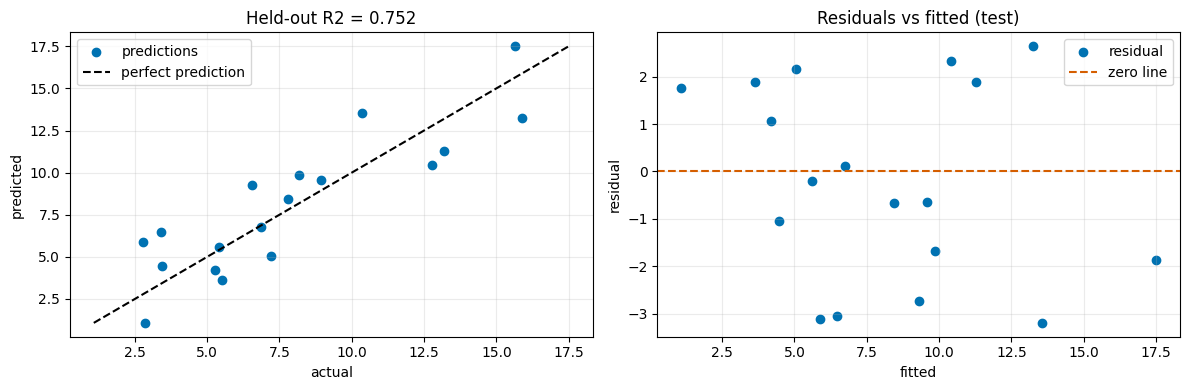

In [3]:
test_pred = ols.predict(X_test)
residuals = y_test - test_pred

baseline = DummyRegressor(strategy='mean').fit(X_train, y_train)
base_r2 = r2_score(y_test, baseline.predict(X_test))
cv_r2 = cross_val_score(LinearRegression(), X_train, y_train, cv=5, scoring='r2')

print(f'Mean-baseline test R2      : {base_r2:.3f}')
print(f'OLS held-out test R2       : {r2_score(y_test, test_pred):.3f}')
print(f'OLS 5-fold CV R2 (train)   : {cv_r2.mean():.3f} +/- {cv_r2.std():.3f}')

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
lim = [min(y_test.min(), test_pred.min()), max(y_test.max(), test_pred.max())]
ax[0].scatter(y_test, test_pred, color=OKABE_ITO[0], label='predictions')
ax[0].plot(lim, lim, color='black', ls='--', label='perfect prediction')
ax[0].set(title=f'Held-out R2 = {r2_score(y_test, test_pred):.3f}',
          xlabel='actual', ylabel='predicted')
ax[0].legend(); ax[0].grid(alpha=0.25)
ax[1].scatter(test_pred, residuals, color=OKABE_ITO[0], label='residual')
ax[1].axhline(0, color=OKABE_ITO[3], ls='--', label='zero line')
ax[1].set(title='Residuals vs fitted (test)', xlabel='fitted', ylabel='residual')
ax[1].legend(); ax[1].grid(alpha=0.25)
plt.tight_layout(); plt.show()


## 4. Why regularization? (CV-selected Ridge and Lasso)
With many correlated or noisy features, OLS can overfit. Ridge (L2) shrinks all coefficients; Lasso (L1) can zero some out. Scaling lives **inside a Pipeline** and alpha is chosen by CV on training data. Coefficient series use distinct markers as well as colors.

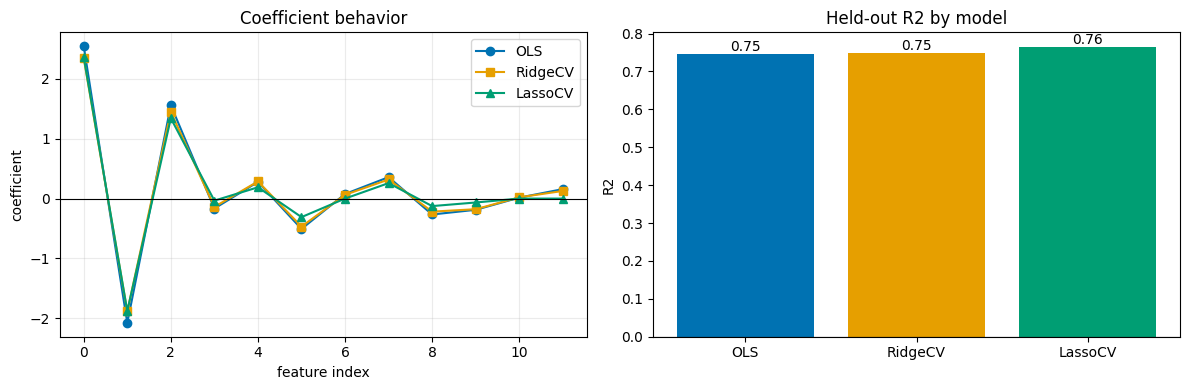

Held-out R2:
  OLS     : 0.747
  RidgeCV : 0.748
  LassoCV : 0.765


In [4]:
X = rng.normal(size=(150, 12))
truth = np.array([2.5, -2, 1.5, 0, 0, 0, 0, 0, 0, 0, 0, 0])
target = X @ truth + rng.normal(0, 2, size=150)
Xtr, Xte, ytr, yte = train_test_split(X, target, test_size=0.3, random_state=7)
alphas = np.logspace(-2, 3, 40)

models = {
    'OLS': LinearRegression(),
    'RidgeCV': Pipeline([('scale', StandardScaler()),
                         ('model', RidgeCV(alphas=alphas))]),
    'LassoCV': Pipeline([('scale', StandardScaler()),
                         ('model', LassoCV(alphas=alphas, cv=5, max_iter=20000,
                                           random_state=0))]),
}
markers = ['o', 's', '^']
scores = {}
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
for i, (name, m) in enumerate(models.items()):
    m.fit(Xtr, ytr)
    scores[name] = r2_score(yte, m.predict(Xte))
    coef = m.coef_ if name == 'OLS' else m.named_steps['model'].coef_
    ax[0].plot(coef, color=OKABE_ITO[i], marker=markers[i], ls='-',
               label=name)
ax[0].axhline(0, color='black', lw=0.8)
ax[0].set(title='Coefficient behavior', xlabel='feature index', ylabel='coefficient')
ax[0].legend(); ax[0].grid(alpha=0.25)

bars = ax[1].bar(list(scores), list(scores.values()),
                 color=[OKABE_ITO[0], OKABE_ITO[1], OKABE_ITO[2]])
ax[1].axhline(0, color='black', lw=0.8)
ax[1].set(title='Held-out R2 by model', ylabel='R2')
for b, v in zip(bars, scores.values()):
    ax[1].text(b.get_x() + b.get_width() / 2, v, f'{v:.2f}',
               ha='center', va='bottom')
plt.tight_layout(); plt.show()

print('Held-out R2:')
for name, s in scores.items():
    print(f'  {name:<8}: {s:.3f}')


## 5. Logistic regression: probabilities, threshold, confusion matrix, ROC
Logistic regression estimates a probability with the sigmoid; a label requires a threshold. We split **before** fitting, evaluate on held-out test data, show a labeled confusion matrix with a colorbar, and demonstrate the threshold/ROC trade-off.

Held-out accuracy (threshold 0.5): 0.800


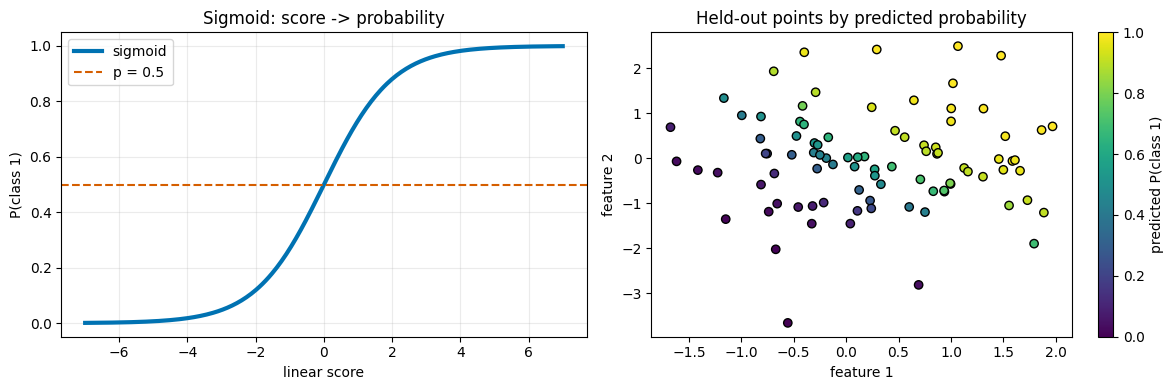

In [5]:
z = np.linspace(-7, 7, 300)
sigmoid = 1 / (1 + np.exp(-z))

Xc = rng.normal(size=(300, 2))
yc = (Xc[:, 0] + 0.8 * Xc[:, 1] + rng.normal(0, 0.65, size=300) > 0).astype(int)
Xc_tr, Xc_te, yc_tr, yc_te = train_test_split(
    Xc, yc, test_size=0.3, random_state=7, stratify=yc
)
clf = Pipeline([('scale', StandardScaler()),
                ('model', LogisticRegression())]).fit(Xc_tr, yc_tr)
test_prob = clf.predict_proba(Xc_te)[:, 1]
test_label = (test_prob >= 0.5).astype(int)
print(f'Held-out accuracy (threshold 0.5): {accuracy_score(yc_te, test_label):.3f}')

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(z, sigmoid, color=OKABE_ITO[0], lw=3, label='sigmoid')
ax[0].axhline(0.5, color=OKABE_ITO[3], ls='--', label='p = 0.5')
ax[0].set(title='Sigmoid: score -> probability', xlabel='linear score',
          ylabel='P(class 1)')
ax[0].legend(); ax[0].grid(alpha=0.25)
sc = ax[1].scatter(Xc_te[:, 0], Xc_te[:, 1], c=test_prob, cmap='viridis',
                   edgecolor='black', vmin=0, vmax=1)
cbar = fig.colorbar(sc, ax=ax[1]); cbar.set_label('predicted P(class 1)')
ax[1].set(title='Held-out points by predicted probability',
          xlabel='feature 1', ylabel='feature 2')
plt.tight_layout(); plt.show()


ROC AUC (test): 0.911


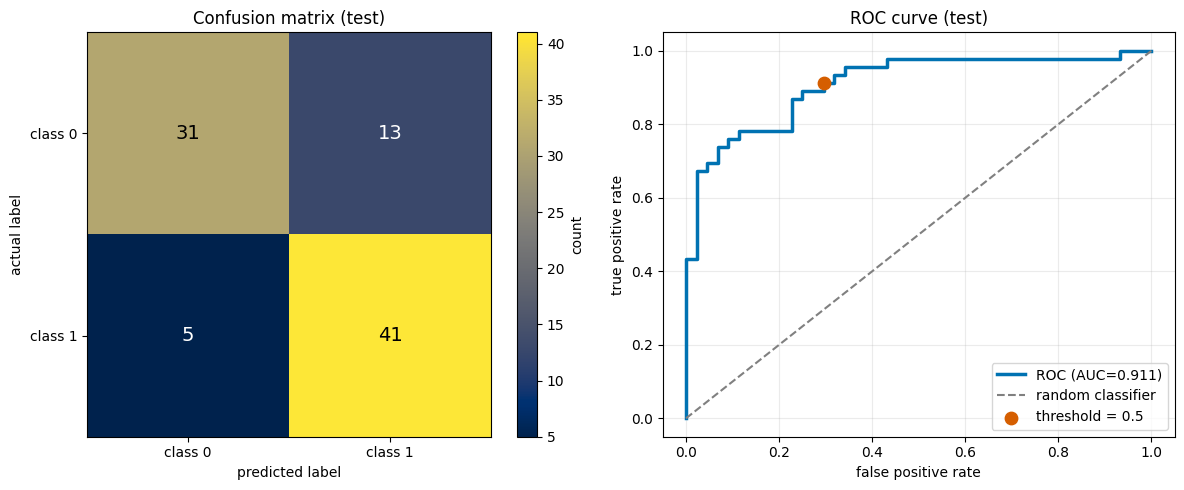

In [6]:
cm = confusion_matrix(yc_te, test_label)
labels = ['class 0', 'class 1']
fpr, tpr, thr = roc_curve(yc_te, test_prob)
auc = roc_auc_score(yc_te, test_prob)
idx = np.argmin(np.abs(thr - 0.5))
print(f'ROC AUC (test): {auc:.3f}')

fig, ax = plt.subplots(1, 2, figsize=(12, 5))
im = ax[0].imshow(cm, cmap='cividis')
cbar = fig.colorbar(im, ax=ax[0]); cbar.set_label('count')
ax[0].set_xticks([0, 1]); ax[0].set_xticklabels(labels)
ax[0].set_yticks([0, 1]); ax[0].set_yticklabels(labels)
ax[0].set(title='Confusion matrix (test)', xlabel='predicted label',
          ylabel='actual label')
thresh_col = cm.max() / 2
for i in range(2):
    for j in range(2):
        ax[0].text(j, i, cm[i, j], ha='center', va='center', fontsize=14,
                   color='white' if cm[i, j] < thresh_col else 'black')
ax[1].plot(fpr, tpr, color=OKABE_ITO[0], lw=2.5, label=f'ROC (AUC={auc:.3f})')
ax[1].plot([0, 1], [0, 1], color='0.5', ls='--', label='random classifier')
ax[1].scatter([fpr[idx]], [tpr[idx]], color=OKABE_ITO[3], marker='o', s=80,
              zorder=5, label='threshold = 0.5')
ax[1].set(title='ROC curve (test)', xlabel='false positive rate',
          ylabel='true positive rate')
ax[1].legend(); ax[1].grid(alpha=0.25)
plt.tight_layout(); plt.show()


## 6. Practical checklist
1. Define the target and metric.
2. **Split before** learning any preprocessing.
3. Fit a simple baseline and compare against the mean baseline.
4. Diagnose residuals, normality (Q–Q), and feature scale/collinearity (VIF).
5. Use cross-validation on training data for regularization strength.
6. Report held-out performance once, with limitations.

**Key caution:** a model captures associations; it does not by itself establish causation.